In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

In [2]:
x_train_pre = joblib.load('x_train_presplit_smote.pkl')
y_train_pre = joblib.load('y_train_presplit_smote.pkl')
x_test_pre  = joblib.load('x_test_presplit_smote.pkl')
y_test_pre  = joblib.load('y_test_presplit_smote.pkl')


In [3]:
lgbm_model_pre = LGBMClassifier(
    n_estimators=100,
    random_state=20,
    is_unbalance=True
)
lgbm_model_pre.fit(x_train_pre, y_train_pre)

[LightGBM] [Info] Number of positive: 1356, number of negative: 1357
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3130
[LightGBM] [Info] Number of data points in the train set: 2713, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499816 -> initscore=-0.000737
[LightGBM] [Info] Start training from score -0.000737


LGBMClassifier(is_unbalance=True, random_state=20)

In [4]:
lgbm_pred_pre = lgbm_model_pre.predict(x_test_pre)
lgbm_prob_pre = lgbm_model_pre.predict_proba(x_test_pre)[:, 1]
print(lgbm_prob_pre)

[0.95060013 0.68565358 0.88146493 0.39043794 0.98331459 0.03474198
 0.33352926 0.99195621 0.74216148 0.87308343 0.23062209 0.71928598
 0.83930382 0.88478985 0.28756315 0.98567144 0.99418358 0.76733328
 0.7671981  0.50340985 0.01411415 0.09281802 0.00327543 0.00395535
 0.04416233 0.2150096  0.28885842 0.94024756 0.90517996 0.82878858
 0.03464968 0.01191798 0.02044696 0.11873772 0.88190932 0.99055609
 0.28769489 0.06319502 0.06469654 0.18655299 0.06554514 0.39771217
 0.04176205 0.94585155 0.73923538 0.88569944 0.73685617 0.28980451
 0.57908944 0.2395356  0.11094395 0.98310761 0.97241323 0.97828891
 0.98036382 0.21592452 0.68797716 0.84695993 0.12641519 0.15026788
 0.06019239 0.93276711 0.04501296 0.17791254 0.27041653 0.75100426
 0.88253597 0.06712447 0.175831   0.94745026 0.02658266 0.98282561
 0.42803428 0.69608355 0.98428347 0.98095438 0.9555635  0.72805954
 0.91030748 0.93561459 0.73995042 0.02861565 0.08316119 0.68014529
 0.00921373 0.93286091 0.35081686 0.87055883 0.99389606 0.9761

In [5]:
lgbm_accuracy_pre = accuracy_score(y_test_pre, lgbm_pred_pre)
print("LightGBM Accuracy (Pre-split SMOTE):", round(lgbm_accuracy_pre, 4))

LightGBM Accuracy (Pre-split SMOTE): 0.9146


In [6]:
print("Classification Report\n")
print(classification_report(y_test_pre, lgbm_pred_pre))

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       339
           1       0.92      0.91      0.91       340

    accuracy                           0.91       679
   macro avg       0.91      0.91      0.91       679
weighted avg       0.91      0.91      0.91       679



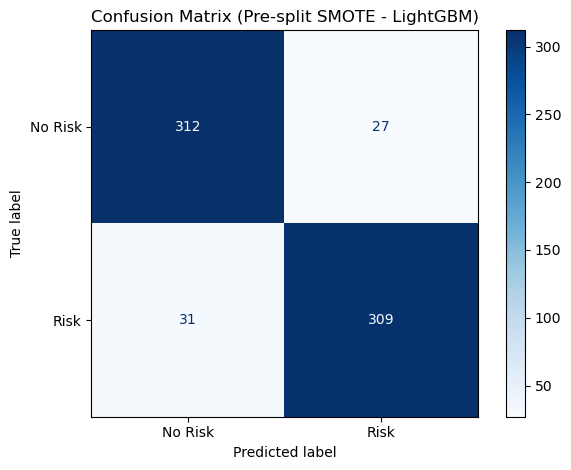

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test_pre, lgbm_pred_pre, display_labels=['No Risk', 'Risk'], cmap='Blues'
)
plt.title("Confusion Matrix (Pre-split SMOTE - LightGBM)")
plt.tight_layout()
plt.show()

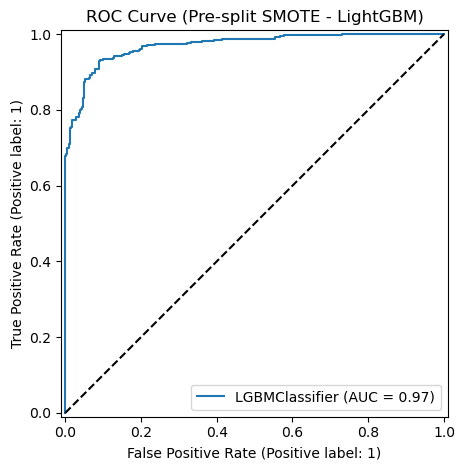

ROC-AUC Score: 0.9703


In [8]:
RocCurveDisplay.from_estimator(lgbm_model_pre, x_test_pre, y_test_pre)
plt.title('ROC Curve (Pre-split SMOTE - LightGBM)')
plt.plot([0, 1], [0, 1], 'k--')
plt.tight_layout()
plt.show()

print('ROC-AUC Score:', roc_auc_score(y_test_pre, lgbm_prob_pre).round(4))

In [9]:
precision_pre = precision_score(y_test_pre, lgbm_pred_pre)
recall_pre    = recall_score(y_test_pre, lgbm_pred_pre)
f1_pre        = f1_score(y_test_pre, lgbm_pred_pre)

print("Precision:", round(precision_pre, 4))
print("Recall   :", round(recall_pre, 4))
print("F1 Score :", round(f1_pre, 4))

Precision: 0.9196
Recall   : 0.9088
F1 Score : 0.9142


In [10]:
feature_names_pre = joblib.load('feature_names_presplit_smote.pkl')  # saved earlier
n_importances = len(lgbm_model_pre.feature_importances_)

print("x_train_pre shape:", x_train_pre.shape)

if len(feature_names_pre) == n_importances:
    labels = feature_names_pre
else:
    labels = [f"feature_{i}" for i in range(n_importances)]

feature_importance_pre = pd.DataFrame({
    "Feature":    labels,
    "Importance": lgbm_model_pre.feature_importances_
})

feature_importance_pre = feature_importance_pre.sort_values(by="Importance", ascending=False)
print(feature_importance_pre.to_string(index=False))

x_train_pre shape: (2713, 28)
 Feature  Importance
       9         279
      10         213
      13         191
       8         183
      12         179
       6         177
       7         176
      15         174
      11         170
      14         167
      18         156
       0         147
      16         138
      21          77
      24          76
      23          61
      19          59
      25          57
       1          50
      22          47
      26          46
      17          45
      20          45
      27          38
       4          19
       2          16
       3          14
       5           0


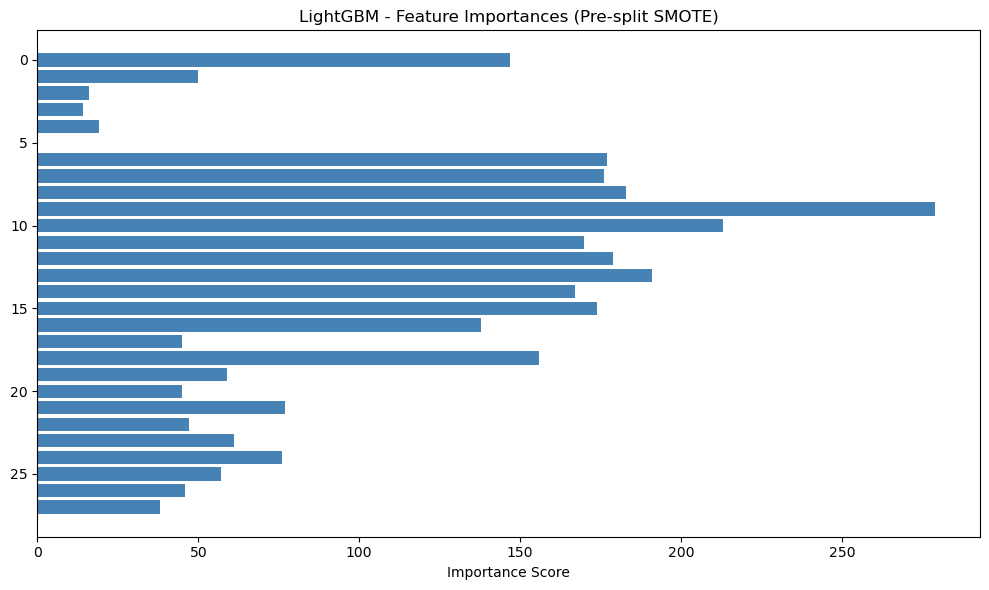

In [11]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_pre["Feature"], feature_importance_pre["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("LightGBM - Feature Importances (Pre-split SMOTE)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
train_pred_pre = lgbm_model_pre.predict(x_train_pre)
print("Train Accuracy:", round(accuracy_score(y_train_pre, train_pred_pre), 4))
print("Test Accuracy :", round(lgbm_accuracy_pre, 4))

Train Accuracy: 1.0
Test Accuracy : 0.9146


In [19]:
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search_pre = GridSearchCV(
    LGBMClassifier(random_state=20, is_unbalance=True),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_pre.fit(x_train_pre, y_train_pre)

[LightGBM] [Info] Number of positive: 1356, number of negative: 1357
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3130
[LightGBM] [Info] Number of data points in the train set: 2713, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499816 -> initscore=-0.000737
[LightGBM] [Info] Start training from score -0.000737
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

GridSearchCV(cv=5, estimator=LGBMClassifier(is_unbalance=True, random_state=20),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [20]:
print("Best Params:", grid_search_pre.best_params_)
best_model_pre = grid_search_pre.best_estimator_


Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}


In [18]:
best_pred_pre = best_model_pre.predict(x_test_pre)
best_prob_pre = best_model_pre.predict_proba(x_test_pre)[:, 1]
print("Best Model Accuracy:", round(accuracy_score(y_test_pre, best_pred_pre), 4))
print("Best Model ROC-AUC :", roc_auc_score(y_test_pre, best_prob_pre).round(4))

Best Model Accuracy: 0.9278
Best Model ROC-AUC : 0.9808


In [15]:
cv_scores_pre = cross_val_score(lgbm_model_pre, x_train_pre, y_train_pre, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores_pre.round(4))
print("Mean:", cv_scores_pre.mean().round(4), "| Std dev:", cv_scores_pre.std().round(4))

[LightGBM] [Info] Number of positive: 1085, number of negative: 1085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3130
[LightGBM] [Info] Number of data points in the train set: 2170, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 1085, number of negative: 1085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3129
[LightGBM] [Info] Number of data points in the train set: 2170, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 1084, number of negative: 1086
[LightGBM] [Info] Auto-choosing col-wise multi-threading, t

In [16]:
joblib.dump(lgbm_model_pre, 'lgbm_model_presplit_smote.pkl')
print("Model saved.")

Model saved.
